# Latent distribution of a backdoored ViT

What the trigger does to the representation, layer by layer.

The whole setup is one call. `load_latent_case` reads the checkpoint's own
`args.json` for the dataset, attack and target label, builds the same test images
twice (once clean, once triggered) and reads the residual stream at every block.
Row `i` of the clean features and row `i` of the backdoor features are the same
image, which is what the paired statistics need.

Everything below is a library function from `analysis`, so a script and a
test call exactly the same code this notebook does.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from analysis.cases import case_distribution_table, load_latent_case
from visualization.distribution_plots import (
    plot_distance_distribution,
    plot_embedding_scatter,
    plot_layer_profile,
    plot_projection_histogram,
)

torch.manual_seed(0)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

device: cuda


## Load one case

`vit_cifar100_badnet_a2o_0_01` is the headline cell: ViT-B/16, CIFAR-100, a BadNet
patch trigger, all-to-one, 1 percent poisoning.

In [2]:
case = load_latent_case("vit_cifar100_badnet_a2o_0_01", samples=1000)

print(f"folder        {case.folder}")
print(f"architecture  {case.architecture}")
print(f"dataset       {case.dataset}")
print(f"attack        {case.attack}")
print(f"target label  {case.target_label}")
print(f"layers        {case.layers[0]} to {case.layers[-1]}")
print(f"samples       {case.clean_features[0].shape[0]}")
print(f"feature dim   {case.clean_features[0].shape[1]}")

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


folder        vit_cifar100_badnet_a2o_0_01
architecture  vit
dataset       cifar100
attack        badnet_a2o
target label  0
layers        0 to 12
samples       1000
feature dim   768


## The per-layer distribution table

Each row asks a different question about the same pair of populations.

| column | question |
|---|---|
| `direction_norm` | how far the trigger moves the mean representation |
| `separation_auroc` | how separable the two populations are along that direction |
| `standardized_shift` | the same distance in units of within-population spread |
| `cka` | how similar the two representations are overall, 1 is identical |
| `effective_rank_*` | how many directions each population occupies |
| `mahalanobis_median` | how unusual a triggered image looks under clean variation |
| `target_alignment` | whether the shift points at the target class, or merely somewhere odd |

In [3]:
table = case_distribution_table(case)
frame = pd.DataFrame(table).set_index("layer")
frame.round(3)

,direction_norm,separation_auroc,standardized_shift,cka,effective_rank_clean,effective_rank_backdoor,rank_ratio,mahalanobis_median,target_alignment
layer,,,,,,,,,
0,0.000,0.500,0.000,NaN,NaN,NaN,NaN,NaN,NaN
1,0.029,0.551,0.164,1.000,2.725,2.722,0.999,4.119,-0.059
2,0.109,0.573,0.260,1.000,4.621,4.567,0.988,6.908,0.095
3,0.219,0.619,0.435,0.999,7.210,7.073,0.981,9.640,0.042
4,0.512,0.784,1.115,0.996,11.502,11.374,0.989,12.628,0.083
5,0.654,0.878,1.632,0.996,15.746,15.568,0.989,15.136,0.031
6,1.424,0.997,3.833,0.990,20.706,19.776,0.955,20.839,0.005
7,3.888,1.000,10.157,0.951,32.405,25.150,0.776,38.535,0.034
8,4.982,1.000,10.013,0.808,57.299,26.886,0.469,38.907,0.094


## Where the backdoor appears

Depth is the thing to read here. A trigger that is not yet in the representation
cannot be detected by anything reading that layer, which is why placement matters.

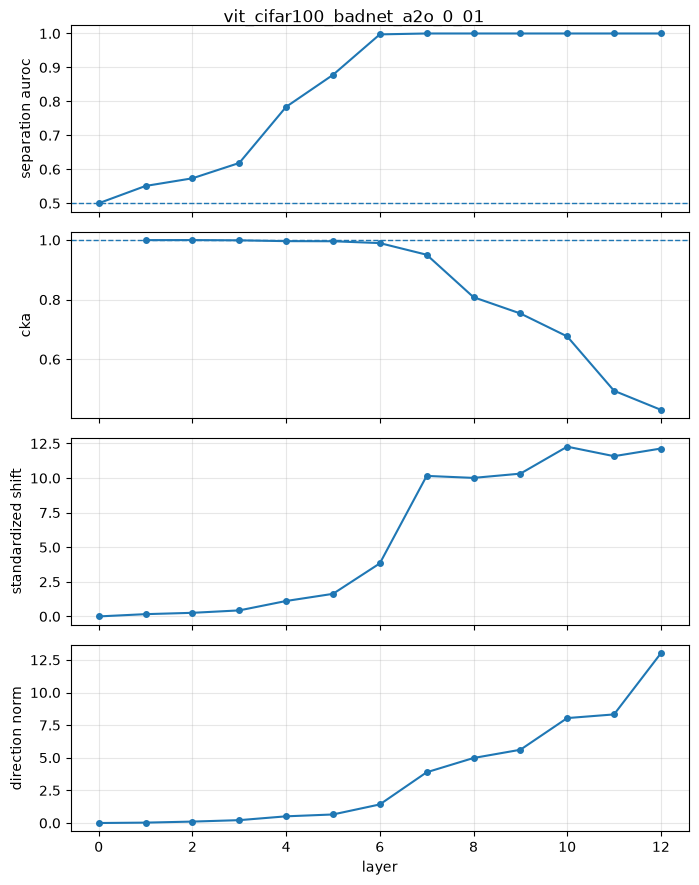

In [4]:
figure = plot_layer_profile(table)
figure.suptitle(f"{case.folder}", y=1.001)
plt.show()

In [5]:
peak = max(table, key=lambda row: row["separation_auroc"])
print(f"most separable layer: {peak['layer']}  auroc {peak['separation_auroc']:.3f}")

first_separable = next(
    (row["layer"] for row in table if row["separation_auroc"] > 0.9), None
)
print(f"first layer above 0.9 auroc: {first_separable}")
peak_layer = int(peak["layer"])

most separable layer: 7  auroc 1.000
first layer above 0.9 auroc: 6


## The distributions themselves

The profile above is a summary. These are the populations it summarizes.

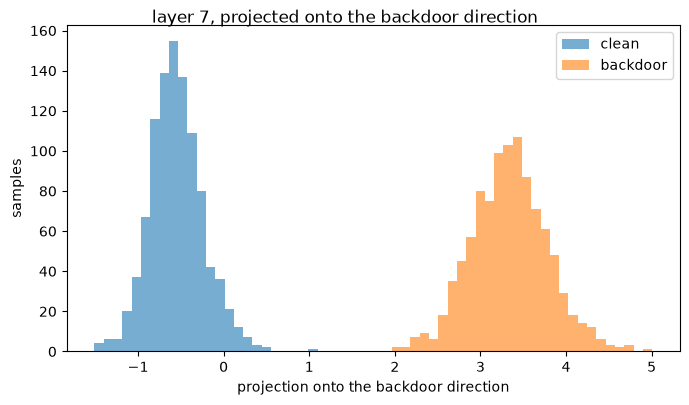

In [6]:
figure = plot_projection_histogram(
    case.clean_features[peak_layer], case.backdoor_features[peak_layer]
)
figure.suptitle(f"layer {peak_layer}, projected onto the backdoor direction", y=1.001)
plt.show()

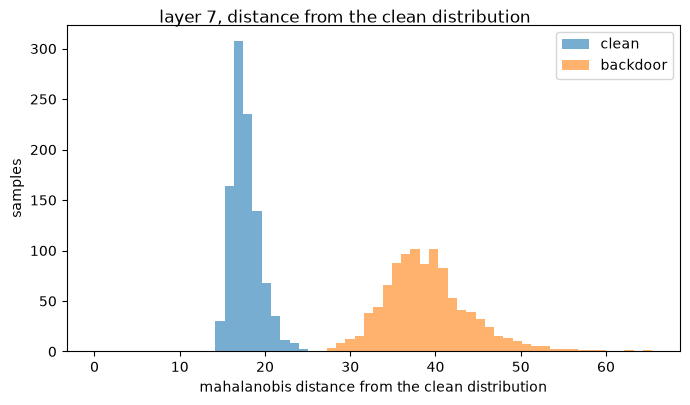

In [7]:
figure = plot_distance_distribution(
    case.clean_features[peak_layer], case.backdoor_features[peak_layer]
)
figure.suptitle(f"layer {peak_layer}, distance from the clean distribution", y=1.001)
plt.show()

## Two dimensions

Both populations are projected together, so the axes mean the same thing for
each. The clean cloud is coloured by true class; if the trigger works by moving
representations into the target class region, the backdoor crosses should land on
one clean cluster rather than off on their own.

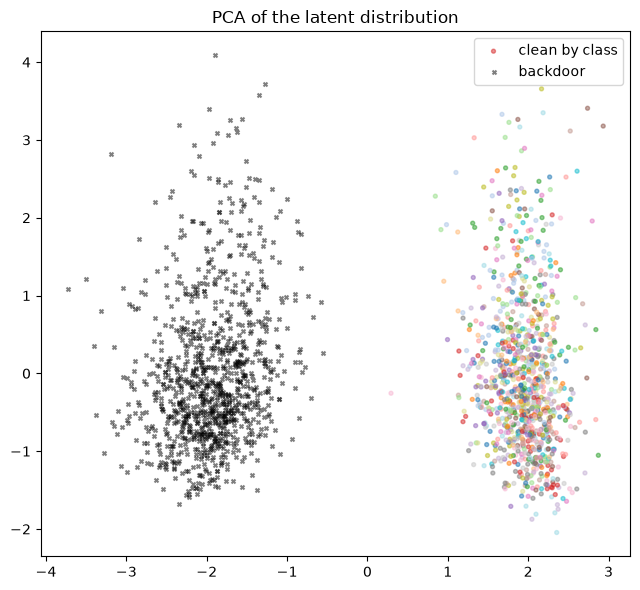

In [8]:
figure = plot_embedding_scatter(
    case.clean_features[peak_layer],
    case.backdoor_features[peak_layer],
    method="pca",
    clean_labels=case.clean_labels,
)
plt.show()

## The negative control

A benign model never learned this trigger. Running the identical pipeline on one
is what separates "the analysis found a backdoor" from "the analysis reacts to any
perturbation of the input".

Do not expect the benign profile to sit at chance. A triggered image really is a
different image, so its representation really does differ, and any statistic
measuring only that difference will rise on a benign model too. What the control
tests is whether the **backdoored** model does something the benign one does not.

In [9]:
benign = load_latent_case(
    "vit_cifar100_benign",
    samples=1000,
    probe_attack="badnet_a2o",
    probe_target_label=0,
)
benign_table = case_distribution_table(benign)

benign_frame = pd.DataFrame(benign_table).set_index("layer")
benign_frame[["separation_auroc", "cka", "target_alignment"]].round(3)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


,separation_auroc,cka,target_alignment
layer,,,
0,0.500,NaN,NaN
1,0.531,1.000,-0.045
2,0.579,1.000,0.174
3,0.614,0.999,0.089
4,0.669,0.997,0.095
5,0.703,0.996,0.068
6,0.760,0.996,0.066
7,0.904,0.993,0.102
8,0.946,0.993,0.052


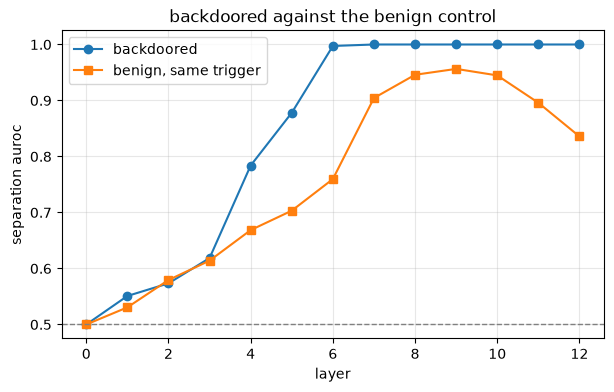

In [10]:
figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(
    [row["layer"] for row in table],
    [row["separation_auroc"] for row in table],
    marker="o",
    label="backdoored",
)
axis.plot(
    [row["layer"] for row in benign_table],
    [row["separation_auroc"] for row in benign_table],
    marker="s",
    label="benign, same trigger",
)
axis.axhline(0.5, ls="--", lw=1, c="grey")
axis.set_xlabel("layer")
axis.set_ylabel("separation auroc")
axis.set_title("backdoored against the benign control")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

A benign model still separates a triggered image from its clean twin, because the
trigger really does change the pixels. The question the control answers is whether
the separation grows with depth into a class-aligned direction, which is what a
learned backdoor looks like, or stays a shallow input-level difference.